# Customer Segmentation using K-Means Clustering

**Subject:** Predictive Analysis  
**Team Members:**
- Lekhaa — 2423235
- Haripreeth — 2423224
- Aiswarya — 2423204

**Aim:**  
To perform K-Means Clustering on the Mall Customers dataset to identify optimal customer segments, using the Elbow Method to determine the ideal number of clusters, and to interpret the resulting segments.

**Importing Libraries:**

In [2]:
import numpy as np                      # numpy is imported for numerical operations
import pandas as pd                     # pandas is imported to load a the dataset in a DataFrame format

import matplotlib.pyplot as plt         # matplotlib is imported for plotting the elbow curve and cluster scatter plots
import seaborn as sns                   # seaborn is imported for enhanced, statistically-aware visualizations

**Import Data from Source:**

In [3]:
df = pd.read_csv(r"C:\Users\Lekhaa\Downloads\Mall_Customers.csv")  # loads the Mall Customers dataset into a pandas DataFrame named df
df.head(5)                              # displays the first 5 rows to confirm the data has loaded correctly and check column names

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(f"Shape of Data: {df.shape}")     # prints (rows, columns) -> confirms we have 200 customer records across 5 attributes

Shape of Data: (200, 5)


In [4]:
print("Info of Data:")                  # prints a header label before the info table for readability
df.info()                               # shows column data types and non-null counts -> confirms no missing values and correct dtypes (int/object)

Info of Data:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
print("Missing Values in our Data:")     # prints a header label before the missing-value summary
df.isnull().sum()                       # counts nulls per column -> confirms the dataset is clean with zero missing values, so no imputation is needed

Missing Values in our Data:


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
print("Statistical Summary of Data:")   # prints a header label before the descriptive statistics table
df.describe()                           # shows mean, std, min, max, quartiles -> Age ranges ~18-70, Income ~15-137k, Spending Score 1-100, giving a sense of scale before clustering

Statistical Summary of Data:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Select Clustering Features:**

We use **Annual Income** and **Spending Score** as the clustering features, since together they best capture purchasing behaviour and are the two variables most relevant to segmenting customers for marketing purposes.

In [7]:
df.columns                              # lists all column names -> used to confirm exact spelling/casing before selecting features (e.g. "Annual Income (k$)")

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [8]:
X = df[
    [
        "Annual Income (k$)",           # selects Annual Income as the first clustering feature (x-axis)
        "Spending Score (1-100)"        # selects Spending Score as the second clustering feature (y-axis)
    ]
]
X.head(5)                               # previews the reduced feature set that will actually be fed into K-Means

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Visualize Raw Customer Data:**

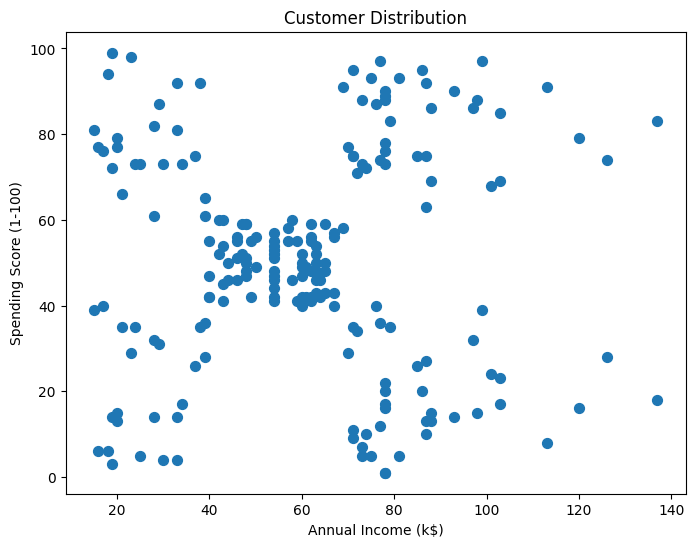

In [9]:
plt.figure(figsize=(8,6))               # creates a new figure of size 8x6 inches to hold the scatter plot

plt.scatter(
    X["Annual Income (k$)"],            # plots Annual Income along the x-axis
    X["Spending Score (1-100)"],        # plots Spending Score along the y-axis
    s=50                                 # sets marker size to 50 so points are clearly visible
)

plt.xlabel("Annual Income (k$)")        # labels the x-axis for readability
plt.ylabel("Spending Score (1-100)")    # labels the y-axis for readability
plt.title("Customer Distribution")      # sets the plot title

plt.show()                              # renders the plot -> shows an unlabeled cloud of points with no visible groupings yet, motivating the need for clustering

These are our customers before applying any clustering algorithm — there are no cluster labels yet, and the plot alone hints at a few visually separable blobs, which K-Means should be able to recover.

**K-Means Clustering with Elbow Method:**

In [10]:
from sklearn.cluster import KMeans      # imports the KMeans class from scikit-learn, the algorithm we will use to find segments

**Determine the optimal number of clusters using the Elbow Method:**

In [11]:
inertia = []                             # initializes an empty list to store the within-cluster sum of squares (WCSS) for each k

K_range = range(1,11)                   # defines the range of candidate cluster counts to test, from k=1 to k=10

for k in K_range:                       # loops over each candidate value of k
    km = KMeans(
        n_clusters=k,                   # sets the number of clusters to try for this iteration
        random_state=42,                # fixes the random seed so results are reproducible across runs
        n_init=10                       # runs the algorithm 10 times with different centroid seeds and keeps the best result, avoiding poor local minima
    )

    km.fit(X)                           # fits the K-Means model on the selected features (Annual Income, Spending Score)

    inertia.append(km.inertia_)         # stores the model's inertia (WCSS) -> a measure of how tightly packed the clusters are for this k

**Plot Elbow Curve:**

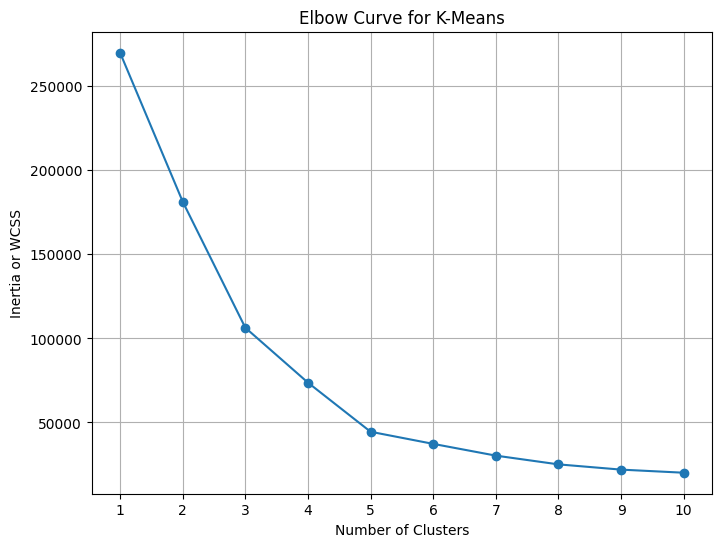

In [12]:
plt.figure(figsize=(8,6))               # creates a new figure to hold the elbow curve

plt.plot(
    K_range,                            # plots the tested k values on the x-axis
    inertia,                            # plots the corresponding inertia values on the y-axis
    marker="o"                          # marks each data point with a circle for clarity
)

plt.xlabel("Number of Clusters")        # labels the x-axis
plt.ylabel("Inertia or WCSS")           # labels the y-axis
plt.title("Elbow Curve for K-Means")    # sets the plot title

plt.xticks(K_range)                     # forces integer tick marks for every tested k, avoiding misleading fractional ticks
plt.grid(True)                          # adds gridlines to make it easier to read off the elbow point
plt.show()                              # renders the plot -> inertia drops sharply up to k=5 and then flattens, marking k=5 as the "elbow" and hence the optimal number of clusters

**Interpretation of the Elbow Method:** The curve shows a steep decline in WCSS as k increases from 1 to 5, after which the rate of decrease slows considerably (the "elbow"). This indicates that adding clusters beyond 5 gives diminishing returns in compactness, so **k = 5** is chosen as the optimal number of segments.

**Final K-Means Model:**

In [13]:
optimal_k = 5                            # sets the optimal number of clusters identified from the elbow curve

kmeans = KMeans(
    n_clusters=optimal_k,                # builds the final KMeans model with the chosen k=5
    random_state=42,                     # fixes the random seed for reproducibility
    n_init=10                            # runs multiple initializations and keeps the best-scoring result
)

df["KMeans"] = kmeans.fit_predict(X)    # fits the model on X and assigns each customer a cluster label (0-4), stored as a new column

df.head()                               # previews the DataFrame -> confirms each customer now has an assigned "KMeans" segment label

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


**Visualize K-Means Clusters:**

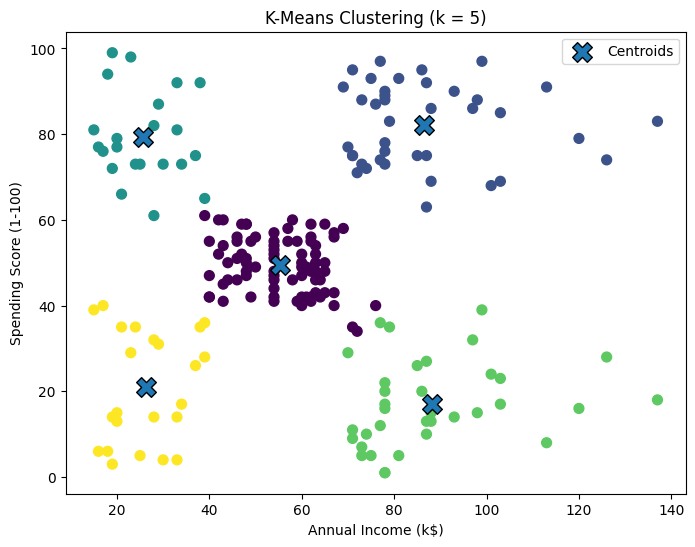

In [14]:
plt.figure(figsize=(8,6))               # creates a new figure for the cluster visualization

plt.scatter(
    X["Annual Income (k$)"],            # plots Annual Income on the x-axis
    X["Spending Score (1-100)"],        # plots Spending Score on the y-axis
    c=df["KMeans"],                     # colors each point according to its assigned cluster label
    s=50,                                # sets marker size for visibility
    cmap="viridis"                      # uses the viridis colormap to visually distinguish clusters
)

# Plot Cluster Centroids:
plt.scatter(
    kmeans.cluster_centers_[:,0],       # plots the x-coordinate (Annual Income) of each cluster centroid
    kmeans.cluster_centers_[:,1],       # plots the y-coordinate (Spending Score) of each cluster centroid
    s=200,                               # makes centroid markers larger than data points so they stand out
    marker="X",                          # uses an X marker shape to visually distinguish centroids from data points
    edgecolors="black",                  # adds a black outline to centroids for extra contrast
    label="Centroids"                    # labels centroids in the legend
)

plt.xlabel("Annual Income (k$)")        # labels the x-axis
plt.ylabel("Spending Score (1-100)")    # labels the y-axis
plt.title("K-Means Clustering (k = 5)") # sets the plot title, indicating the chosen k
plt.legend()                            # displays the legend so centroids are identifiable

plt.show()                              # renders the plot -> shows five visually distinct, well-separated customer segments with centroids marking each group's center

**Segment Profiling:**

In [15]:
cluster_summary = df.groupby("KMeans")[["Age","Annual Income (k$)","Spending Score (1-100)"]].mean().round(1)  # computes the average Age, Income, and Spending Score per cluster to profile each segment

cluster_summary["Count"] = df["KMeans"].value_counts().sort_index()  # adds the number of customers in each cluster to the summary table

cluster_summary                         # displays the profiling table -> used to interpret and label each segment (e.g. high-income/high-spending, low-income/high-spending, etc.)

,Age,Annual Income (k$),Spending Score (1-100),Count
KMeans,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


**Interpretation of Segments** (based on the `cluster_summary` table produced by this run, with `random_state=42`):
- **Cluster 0** (Age ~43, Income ~55k, Score ~50, 81 customers): Average income and average spending — the largest, "typical" customer segment.
- **Cluster 1** (Age ~33, Income ~87k, Score ~82, 39 customers): High income and high spending score — the most valuable segment; ideal target for premium products and loyalty programs.
- **Cluster 2** (Age ~25, Income ~26k, Score ~79, 22 customers): Low income but high spending score — younger, impulsive/trend-driven spenders with strong marketing responsiveness.
- **Cluster 3** (Age ~41, Income ~88k, Score ~17, 35 customers): High income but low spending score — cautious, price-sensitive despite high earning power; a good target for re-engagement offers.
- **Cluster 4** (Age ~45, Income ~26k, Score ~21, 23 customers): Low income and low spending score — budget-conscious customers, lowest priority for premium campaigns.

(Cluster numbers are arbitrary labels assigned by KMeans and not ordered by value — they will match this description as long as `random_state=42` is kept unchanged.)

**Conclusion:**

The Elbow Method identified **k = 5** as the optimal number of clusters for the Mall Customers dataset based on Annual Income and Spending Score. The resulting K-Means segmentation produced five clearly separated, interpretable customer segments ranging from low-income/low-spending to high-income/high-spending groups. These segments can guide targeted marketing strategies — for instance, prioritizing premium campaigns for the high-income/high-spending segment and re-engagement offers for the high-income/low-spending segment.